# 02 · Which is the low-dimensional channel — a region's own recurrence, or its input?

*Task 02 of the final series. Inherits the base model from task 01; the full network fitted
there is this grid's dense corner.*

Every inter-region block can be forced through $r_c$ dimensions (`recurrent_bottleneck_dim`,
the existing constraint) and, newly, every region's own recurrent block through $r_w$
dimensions (`within_region_bottleneck_dim`). The grid is every pair
$(r_w, r_c) \in \{1,2,3,5,10\}^2$, refitted from scratch, five seeds each.

**Why the grid needs its marginals.** A region's pre-activation is one within block plus
three cross blocks, $W_{rr}h_r + \sum_{s\neq r} W_{rs}h_s$, so its rank is bounded by

$$r_{\text{drive}} \;=\; r_w + 3\,r_c .$$

At equal rank the cross constraint removes about three times as many drive dimensions as the
within constraint. Inside the grid the two are always mixed, and "cross matters more" would
be true by counting alone. So two more arms are fitted with one side left **dense**:
$(\text{dense}, r_c)$ isolates the pure cost of squeezing the inter-regional channel with
self-recurrence free to compensate, and $(r_w, \text{dense})$ the reverse. Laid side by side
they are the clean comparison; plotted against $r_{\text{drive}}$ they are the check on
whether the comparison at equal rank means anything.

**Read the worst cell, not the mean.** Under the minimax objective the twelve region ×
condition cells degrade together, so the worst is representative — and it is the quantity
the objective minimised, so convergence and adequacy are one curve.

| Section | |
|---|---|
| 1 | Inherited base model and the cells |
| 2 | Run state and submission (off by default) |
| 3 | Convergence |
| 4 | The grid |
| 5 | The marginals, and total drive rank |
| 6 | Selecting the bottleneck for task 03 |
| 7 | Reading the result |

**Nothing here submits a job unless `SUBMIT` is set to `True`.**

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
PROTOCOL_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
LADDER_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
TASK_ROOT = sweep.resolve_task_root("02_rank_grid", DATASET_CFG_PATH, tree=TREE)
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_02_rank_grid")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

SELECTED_PROTOCOL, PROTOCOL_IS_PROVISIONAL = sweep.load_selected_protocol_or_provisional(
    PROTOCOL_ROOT / "selected_protocol.yaml")
BASE = yaml.safe_load((TASK_ROOT.parent / "base_model.yaml").read_text())
REGION_ORDER = tuple(BASE.pop("region_order"))
BASE.pop("inherited_protocol", None); BASE.pop("r2_centring", None)
HIDDEN_UNITS = int(BASE["hidden_units"])

RANKS = (1, 2, 3, 5, 10)
GRID_SEEDS = 5

#: The matched per-cell ceiling task 01 computes (see its Section 1); the old per-region
#: ceiling only as a fallback before it exists.
_cell_path = TASK_ROOT.parent / "pc_space_ceiling_by_cell.csv"
if _cell_path.exists():
    _cell = pd.read_csv(_cell_path)
    ceiling_by_region = _cell[_cell["condition"] == "all"].set_index("region")["reliability"].to_dict()
    ceiling_by_cell = {(r, c): v for r, c, v in _cell[_cell["condition"] != "all"]
                       [["region", "condition", "reliability"]].itertuples(index=False)}
else:
    ceiling_by_region = (pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
                         .groupby("region")["reliability"].mean().to_dict())
    ceiling_by_cell = None
ADEQUATE_BAR = 0.98


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


print("base model:", BASE)
print("task root :", TASK_ROOT)

base model: {'hidden_units': 40, 'recurrent_connectivity': 'full', 'recurrent_bottleneck_dim': None, 'within_region_bottleneck_dim': None, 'l1_weight_scale': 0.0, 'loss_aggregation': 'minimax', 'minimax_temperature': 0.01, 'condition_loss_weighting': 'uniform', 'pc_loss_weighting': 'uniform'}
task root : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/final/02_rank_grid


In [2]:
variants = audit.rank_grid_variants(RANKS, base_overrides=BASE, include_marginals=True)
seeds = protocol.protocol_seeds(n_seeds=GRID_SEEDS)
counts = pd.Series([v.arm for v in variants]).value_counts()
display(pd.DataFrame([v.describe() for v in variants])[
    ["label", "arm", "within_region_bottleneck_dim", "recurrent_bottleneck_dim"]])
display(Markdown(
    f"**{len(variants)} cells × {GRID_SEEDS} seeds = {len(variants) * GRID_SEEDS} runs** "
    f"({counts.get('grid', 0)} grid + {counts.get('cross-region marginal', 0)} + "
    f"{counts.get('within-region marginal', 0)} marginal cells). The dense corner is task 01's "
    f"`full` arm and is not refitted here."))

,label,arm,within_region_bottleneck_dim,recurrent_bottleneck_dim
0,w1_c1,grid,1.0,1.0
1,w1_c2,grid,1.0,2.0
2,w1_c3,grid,1.0,3.0
3,w1_c5,grid,1.0,5.0
4,w1_c10,grid,1.0,10.0
5,w2_c1,grid,2.0,1.0
6,w2_c2,grid,2.0,2.0
7,w2_c3,grid,2.0,3.0
8,w2_c5,grid,2.0,5.0
9,w2_c10,grid,2.0,10.0


**35 cells × 5 seeds = 175 runs** (25 grid + 5 + 5 marginal cells). The dense corner is task 01's `full` arm and is not refitted here.

In [3]:
SUBMIT = False   # <-- set to True to queue every missing run as one array

flight = sweep.in_flight_run_dirs(TASK_ROOT / "_jobs")
commands, _ = sweep.variant_job_commands(
    variants, seeds, root=TASK_ROOT, repo_root=repo_root,
    protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH, exclude_run_dirs=flight["run_dirs"])
inventory = sweep.index_variant_runs(TASK_ROOT, variants, seeds, in_flight=flight["run_dirs"])
display(Markdown(
    f"**{int(inventory['complete'].sum())} complete**, **{int(inventory['queued'].sum())} queued**, "
    f"**{int(inventory['pending'].sum())} unqueued** of {len(inventory)}."))

if SUBMIT and commands:
    from datetime import datetime
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = TASK_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    job_file = jobs_dir / f"rank_grid_{stamp}.txt"
    write_job_file(job_file, commands)
    submitted = [Path(line.split("--run-dir ")[1].split()[0]) for line in commands]
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / f"rank_grid_{stamp}.sh",
        log_dir=jobs_dir / "logs", job_name="mrnn_rank_grid", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=submitted, label=f"rank grid {stamp}")
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(commands)}** runs as array **{job_id}**."))
elif commands:
    display(Markdown("`SUBMIT` is **False** — nothing was submitted."))
else:
    display(Markdown("The grid is fully trained."))

**175 complete**, **0 queued**, **0 unqueued** of 175.

The grid is fully trained.

## 3. Convergence

A constraint the data cannot tolerate and one the recipe cannot optimise look the same in
the final loss. The trajectories separate them; a cell that fails the bar is reported with
its convergence, not just its number.

In [4]:
done = inventory[inventory["complete"]]
if done.empty:
    display(Markdown("*Nothing trained yet.*"))
    fit = adequacy = None
else:
    display(sweep.convergence_table(sweep.load_histories(done)).round(5))
    fit = cached("grid_fit", lambda: sweep.score_variant_fit(done, ceiling_by_region, ceiling_by_cell=ceiling_by_cell))
    adequacy = audit.annotate_rank_grid(
        sweep.adequacy_table(fit, baseline_label="wdense_cdense"), hidden_units=HIDDEN_UNITS)
    adequacy["clears_bar"] = adequacy["worst_condition"] >= ADEQUATE_BAR
    display(adequacy[["label", "rank_within", "rank_cross", "drive_rank", "worst_condition",
                      "mean_all", "seed_spread", "clears_bar"]].sort_values("drive_rank").round(4))

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,w1_c1,5,5,0,1.00000,0.10459,1.10757
1,w1_c2,5,5,0,1.00001,0.08548,1.11926
2,w1_c3,5,5,0,1.00001,0.07585,1.03863
3,w1_c5,5,5,0,1.00000,0.06853,1.04068
4,w1_c10,5,5,0,1.00001,0.05618,1.04031
5,w2_c1,5,5,0,1.00003,0.09369,1.04857
6,w2_c2,5,5,0,1.00000,0.08276,1.04447
7,w2_c3,5,5,0,1.00005,0.07345,1.12930
8,w2_c5,5,5,0,1.00003,0.06710,1.04702
9,w2_c10,5,5,0,1.00000,0.05588,1.06498


,label,rank_within,rank_cross,drive_rank,worst_condition,mean_all,seed_spread,clears_bar
6,w1_c1,1,1,4,0.9378,0.9457,0.0051,False
12,w2_c1,2,1,5,0.9508,0.9582,0.0016,False
18,w3_c1,3,1,6,0.9478,0.9555,0.0044,False
8,w1_c2,1,2,7,0.9583,0.9649,0.0032,False
24,w5_c1,5,1,8,0.9573,0.9638,0.0014,False
14,w2_c2,2,2,8,0.9598,0.9663,0.0013,False
20,w3_c2,3,2,9,0.9624,0.9683,0.0022,False
9,w1_c3,1,3,10,0.9663,0.9719,0.0012,False
26,w5_c2,5,2,11,0.9652,0.9710,0.0016,False
15,w2_c3,2,3,11,0.9664,0.9720,0.0040,False


## 4. The grid

Worst region × condition cell against the ceiling, every $(r_w, r_c)$. Bold clears the bar.

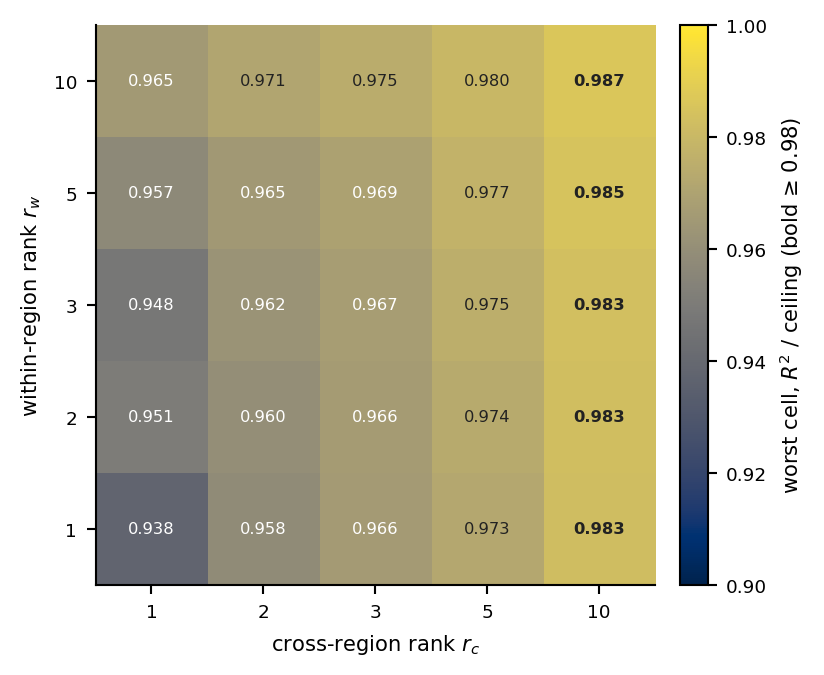

In [5]:
if adequacy is not None:
    show(aviz.plot_rank_grid(adequacy, ranks=RANKS, bar=ADEQUATE_BAR), "fig01_rank_grid")

## 5. The marginals, and total drive rank

Left: squeeze only the inter-regional channel. Middle: squeeze only self-recurrence. Right:
every cell against $r_w + 3\,r_c$. If the grid collapses onto one curve in the right panel,
the two constraints act only through the total number of drive dimensions they remove and
"which matters more" is counting. If the marginals separate *at matched drive rank*, one of
them is the low-dimensional channel in a sense the other is not.

Dense corner (task 01 `full`, 10 seeds): worst cell **0.9913**.

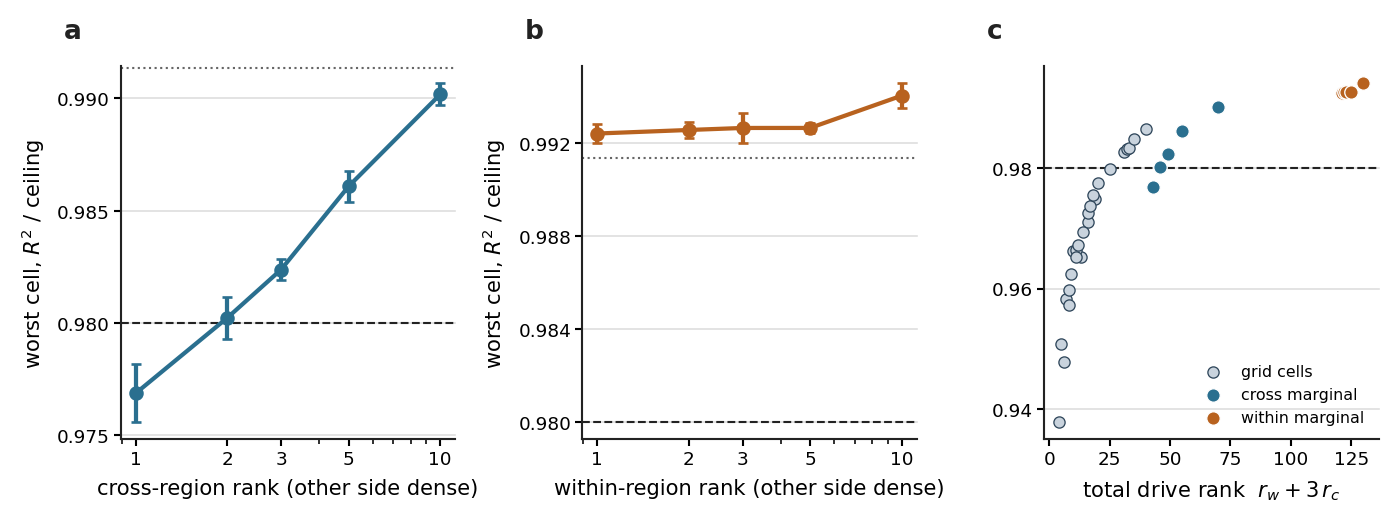

,cross-region marginal (within dense),within-region marginal (cross dense)
1,0.9769,0.9924
2,0.9802,0.9925
3,0.9824,0.9926
5,0.9861,0.9926
10,0.9902,0.9940


In [6]:
if adequacy is not None:
    # The dense corner is task 01's full network, scored on the same ceiling.
    dense_value = None
    full_dirs = audit.seed_run_dirs(LADDER_ROOT / "full")
    if full_dirs:
        full_inv = pd.DataFrame([{"label": "full", "seed": p.name.replace("seed=", ""), "run_dir": str(p),
                                  "complete": True} for p in full_dirs])
        full_fit = sweep.score_variant_fit(full_inv, ceiling_by_region, ceiling_by_cell=ceiling_by_cell)
        dense_value = float(full_fit.groupby("seed")["r2_vs_ceiling"].min().mean())
        display(Markdown(f"Dense corner (task 01 `full`, {len(full_dirs)} seeds): worst cell **{dense_value:.4f}**."))
    show(aviz.plot_rank_marginals(adequacy, ranks=RANKS, dense_value=dense_value, bar=ADEQUATE_BAR),
         "fig02_marginals_and_drive_rank")

    margins = adequacy[adequacy["arm"].str.contains("marginal")] if "arm" in adequacy else adequacy
    cross_m = adequacy[adequacy["label"].str.match(r"^wdense_c\d+$")].set_index("rank_cross")["worst_condition"]
    within_m = adequacy[adequacy["label"].str.match(r"^w\d+_cdense$")].set_index("rank_within")["worst_condition"]
    display(pd.DataFrame({"cross-region marginal (within dense)": cross_m,
                          "within-region marginal (cross dense)": within_m}).round(4))

## 6. Selecting the bottleneck

The tightest grid cell — lowest total drive rank, ties to lower cross rank — whose worst cell
clears the bar. Marginals are excluded: the selected model constrains both sides, and the
marginals exist to interpret it. Written to `selected_bottleneck.yaml` for task 03.

In [7]:
if adequacy is not None:
    chosen = audit.select_bottleneck(adequacy, hidden_units=HIDDEN_UNITS, bar=ADEQUATE_BAR)
    if chosen is None:
        display(Markdown("**No grid cell clears the bar.** Task 03 should fall back to the marginal "
                         "that does, or to the dense model, and say so."))
    else:
        (TASK_ROOT / "selected_bottleneck.yaml").write_text(yaml.safe_dump(chosen, sort_keys=False))
        display(Markdown(
            f"**Selected: `{chosen['label']}`** — within rank {chosen['within_region_bottleneck_dim']}, "
            f"cross rank {chosen['recurrent_bottleneck_dim']}, drive rank {chosen['drive_rank']}, "
            f"worst cell {chosen['worst_condition']:.4f}. Written to `selected_bottleneck.yaml`."))

**Selected: `w1_c10`** — within rank 1, cross rank 10, drive rank 31, worst cell 0.9826. Written to `selected_bottleneck.yaml`.

## 7. Reading the result

**Which is the channel.** The marginals at matched drive rank. The prediction from the
rebuild is that cross-region rank binds first *by counting* — three blocks to one — and that
the interesting question is whether it binds *more* than three-to-one. The right-hand panel
of Section 5 answers that directly.

**Whether the constraints interact.** The grid interior against the two marginals. The
rebuild's sparsity corner failed where each side alone passed; if the same happens here,
the interaction is the finding and it is reported as such.

**What task 03 inherits.** One cell, chosen by a stated rule, refitted ten times. Its job is
to ask what ten fits of the most constrained adequate model agree on.

**Next:** `03_ensemble.ipynb`.